IMPLEMENTING THE CONCEPT OF EARLY STOPPING


WITHOUT EARLYSTOPPING


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense ,Flatten
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 ...
 [-0.13690036 -0.81001183]
 [ 0.67036156 -0.76750154]
 [ 0.28105665  0.96382443]]


<Axes: >

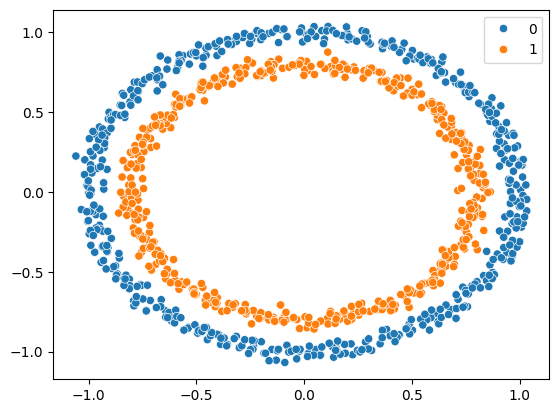

In [ ]:
X,Y=make_circles(n_samples=1000,noise=0.03,random_state=42)# CREATING A DATASET USNING MAKE_CIRCLES
print(X)                                                   # IN FORM OF A ARRAY WHICH CONATINS 2D CORDINATES OF POINTS
#print(y)                                                   # Y CONTAINS THE LABELS 0 AND 1
sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y,)

In [19]:
X_TRAIN ,X_TEST ,Y_TRAIN ,Y_TEST=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
# CREATING A NEURAL NETWORK

model=Sequential()
model.add(Dense(256,input_dim=2,activation="relu"))
model.add(Dense(1,activation="sigmoid"))
model.summary()

e:\MLJOURNEY\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics=['accuracy'])

In [50]:
history=model.fit(X_TRAIN,Y_TRAIN,validation_data=(X_TEST,Y_TEST),epochs=10000)

Epoch 1/10000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0109 - val_accuracy: 1.0000 - val_loss: 0.0246
Epoch 2/10000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0110 - val_accuracy: 1.0000 - val_loss: 0.0237
Epoch 3/10000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0108 - val_accuracy: 1.0000 - val_loss: 0.0235
Epoch 4/10000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 0.0231
Epoch 5/10000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 0.0245
Epoch 6/10000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 0.0230
Epoch 7/10000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0100 - val_accuracy: 1.0000 - val_loss: 0.0239
Epoch 8/10000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0100 - val_accu

KeyboardInterrupt: 

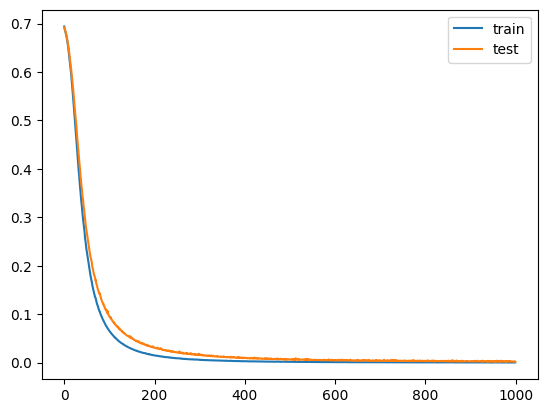

In [51]:
plt.plot(history.history["loss"],label="train")
plt.plot(history.history["val_loss"],label="test")
plt.legend()                                            # PLT.LEGEND() IS USED TO SHOW THE LABELS OF THE LINES.
                                                        # MEANS ITS SHOWS ON TOPRIGHT WHAT COLOUR REPRESENTS WHAT ,
                                                        # IT IS SIMMLIAR TO THE BOX WE MADE IN MATH TO SHOW OUR LABELS ON GRAPH
plt.show()

NOW USING EARLYSTOPPING


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense ,Flatten
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
from tensorflow.keras.callbacks import EarlyStopping  #EARLYSTOPPING IS FUCNTION IN KERAS WHICH IS USIED FRO EARLY STOPPING 

In [42]:
model=Sequential()
model.add(Dense(256,input_dim=2,activation="relu"))
model.add(Dense(1,activation="sigmoid"))
model.summary()

e:\MLJOURNEY\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks=EarlyStopping(
    
    min_delta=0.001,                   # MIN_DELTA IS THE MINIMUM CHANGE IN THE MONITORED VALUE TO CONSIDER THAT MODEL IS IMPROVING NOT OVERFITTING

    verbose=1,                         # VERBOSE=1 WILL PRINT MESSAGES WHEN EARLY STOPPING IS TRIGGERED  {1 MEANS TRUE}

    patience=5,                        # IF VAL_LOSS DOES NOT IMPROVE FOR 5 CONSECUITVE EPOCHS THEN IT WILL STOP THE TRAINING
    
    mode=1,                            # MODE CAN BE 'MIN','MAX' OR 'AUTO' , IN 'MIN' TRAINING WILL STOP WHEN THE MONITORED VALUE STOPS DECREASING , 
                                       #IN 'MAX' IT WILL STOP WHEN THE MONITORED VALUE STOPS INCREASING ,
                                       #  IN 'AUTO' IT WILL DECIDE BASED ON THE NAME OF THE MONITORED VALUE

    baseline=None,                     # IF THE MONITORED VALUE DOES NOT IMPROVE BEYOND THIS BASELINE , TRAINING WILL STOP,IF YOU DONT WANT TO SET BASELINE THEN KEEP IT NONE

    restore_best_weights=True          # IT WILL SELECT  THE BEST WEIGHTS OF THE MODEL WHEN TRAINING STOPS
)

In [ ]:
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics=['accuracy'],)
histoy=model.fit(X_TRAIN,Y_TRAIN,validation_data=(X_TEST,Y_TEST),epochs=1000,callbacks=callbacks)
# CALLBACK IS ADDED IN FIT FUNCTION TO ENABLE EARLY STOPPING

Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0136 - val_accuracy: 1.0000 - val_loss: 0.0298
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0131 - val_accuracy: 1.0000 - val_loss: 0.0283
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 1.0000 - val_loss: 0.0281
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 1.0000 - val_loss: 0.0290
Epoch 5/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0125 - val_accuracy: 1.0000 - val_loss: 0.0266
Epoch 6/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0123 - val_accuracy: 1.0000 - val_loss: 0.0269
Epoch 7/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0121 - val_accuracy: 1.0000 - val_loss: 0.0267
Epoch 8/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0121 - val_accuracy: 1

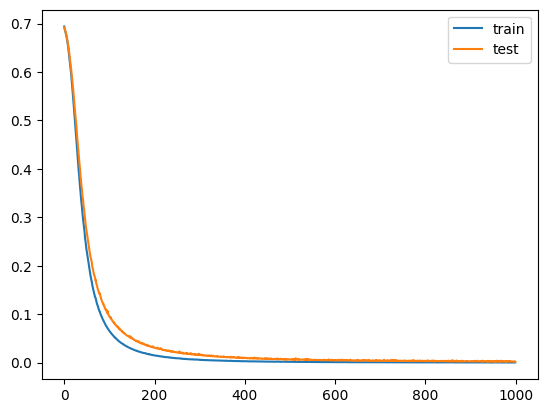

In [49]:
plt.plot(history.history['loss'],label="train")
plt.plot(history.history['val_loss'],label="test")
plt.legend()